# Monte Carlo

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [37]:
# Parametry symulacji

S_0 = 3200 # obecna cena WIG20
q = 0.0 # dywidenda wypłacana w chwili 1 / 2
T = 1.0 # czas do wygaśnięcia opcji w latach
dt = 1 / 10000 # krok czasowy dostosowany do metody binomial tree
sigma_l = 0.2   # dolna granica zmienności
sigma_h = 0.3   # górna granica zmienności
r = 0.05 # stopa wolna od ryzyka
N = 20000 # liczba symulacji, dobrze jakby było >40k, ale problem z pamięcią
seed = 42


In [38]:
# Parametry opcji
K       = 3200    # strike
B_call  = 3600    # bariera Call
B_put   = 2800    # bariera Put 

np.random.seed(seed)

In [39]:
def simulate_paths(S_0, T, dt, sigma, r, N, t_div=0.5, q=0.0):
    M = int(T / dt)  # liczba kroków czasowych
    drift = (r - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt)

    N_half = N // 2
    Z = np.random.standard_normal((N_half, M))
    increments_pos = drift + diffusion * Z
    increments_neg = drift + diffusion * (-Z)
    increments = np.concatenate([increments_pos, increments_neg], axis=0)

    # Z = np.random.standard_normal((N, M))
    # increments = drift + diffusion * Z
    
    log_paths = np.cumsum(increments, axis=1)
    log_paths = np.insert(log_paths, 0, 0, axis=1)

    div_step_index = int(np.ceil(t_div / dt))
    if q > 0 and div_step_index <= M:
        log_paths[:, div_step_index:] += np.log(1 - q)

    paths = S_0 * np.exp(log_paths)

    return paths

In [40]:
def price_european_call_knockout(paths, K, B_call):

    barrier_hit = np.any(paths >= B_call, axis=1)

    survived = (barrier_hit == False)

    S_T = paths[:, -1]
    payoff = np.maximum(S_T - K, 0) * survived

    discount = np.exp(-r * T)
    price = discount * np.mean(payoff)

    return price

In [41]:
paths_l = simulate_paths(S_0, T, dt, sigma_l, r, N, t_div=0.5, q=q)
paths_h = simulate_paths(S_0, T, dt, sigma_h, r, N, t_div=0.5, q=q)

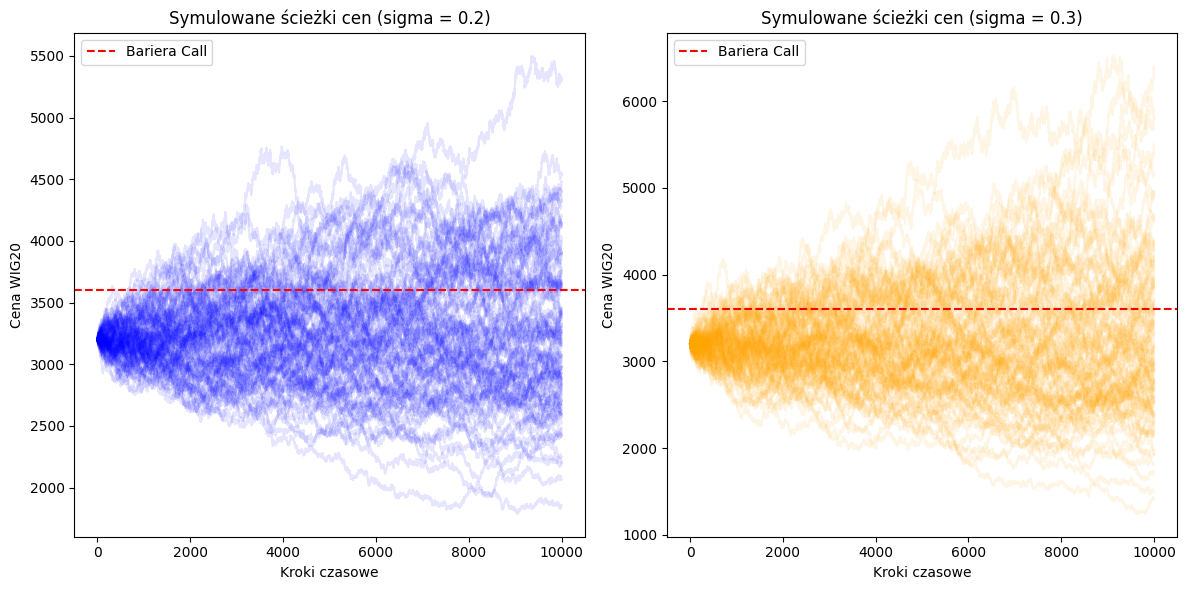

In [42]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(paths_l[:100].T, color='blue', alpha=0.1)
plt.title('Symulowane ścieżki cen (sigma = 0.2)')
plt.xlabel('Kroki czasowe')
plt.ylabel('Cena WIG20')
plt.axhline(B_call, color='red', linestyle='--', label='Bariera Call')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(paths_h[:100].T, color='orange', alpha=0.1)
plt.title('Symulowane ścieżki cen (sigma = 0.3)')
plt.xlabel('Kroki czasowe')
plt.ylabel('Cena WIG20')
plt.axhline(B_call, color='red', linestyle='--', label='Bariera Call')
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
print(f"Cena opcji europejskiej CALL z barierą (dolna zmienność): {price_european_call_knockout(paths_l, K, B_call):.2f}")  
print(f"Cena opcji europejskiej CALL z barierą (górna zmienność): {price_european_call_knockout(paths_h, K, B_call):.2f}")

Cena opcji europejskiej CALL z barierą (dolna zmienność): 9.15
Cena opcji europejskiej CALL z barierą (górna zmienność): 2.72


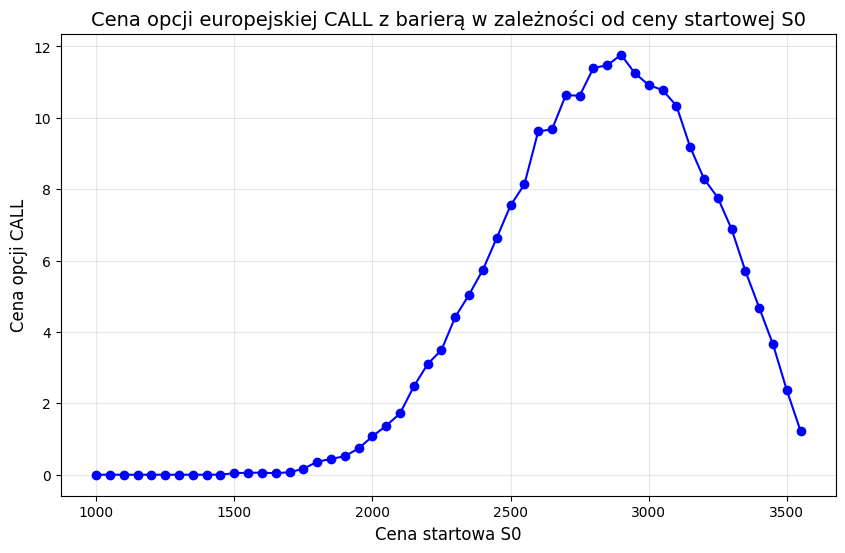

In [44]:
results = []
for S in range(1000, 3551, 50):
    results.append((S, price_european_call_knockout(simulate_paths(S, T, dt, sigma_l, r, N), K, B_call)))

results_df = pd.DataFrame(results, columns=['S0', 'Call_Price'])
results_df.to_csv('wyniki_mc.csv', index=False, sep=';')
plt.figure(figsize=(10, 6))
plt.plot(results_df['S0'], results_df['Call_Price'], marker='o', linestyle='-', color='blue')
plt.title('Cena opcji europejskiej CALL z barierą w zależności od ceny startowej S0', fontsize=14)
plt.xlabel('Cena startowa S0', fontsize=12)
plt.ylabel('Cena opcji CALL', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Za pomocą symulacji Monte Carlo trudno oddać niepewną zmienność w inny sposób niż wykonać symulacje dla różnych wartości zmienności rynkowej, gdyż podejście używane w schemacie różnic skończonych operuje równocześnie na wielu trajektoriach, podczas gdy każda symulacja Monte Carlo to jedna trajektoria. W efekcie stałe wyznaczanie gammy (i na jej podstawie wyznaczanie wartości zmienności) nie jest możliwe.